## Testing HVAC_water_system with process load from file


In [1]:
import opensimula as osm

dict = {
    "name": "Process water system",
    "time_step": 3600,
    "n_time_steps": 8760,
    "initial_time": "01/01/2001 00:00:00",
    "simulation_file_met": "Sevilla",
    "components": [
        {
            "type": "File_met",
            "name": "Sevilla",
            "file_type": "MET",
            "file_name": "../../mets/sevilla.met"
        },
        {
            "type": "File_data",
            "name": "data_file",
            "file_type": "CSV",
            "file_name": "ASHRAE_140_CASE_610.csv",
            "file_step": "SIMULATION"
        },
        {
            "type": "Day_schedule",
            "name": "working_day",
            "time_steps": [28800, 43200],
            "values": [0, 1, 0],
            "interpolation": "STEP",
        },
        {
            "type": "Day_schedule",
            "name": "off_day",
            "time_steps": [],
            "values": [0],
            "interpolation": "STEP",
        },
        {
            "type": "Day_schedule",
            "name": "on_day",
            "time_steps": [],
            "values": [1],
            "interpolation": "STEP",
        },
        {
            "type": "Week_schedule",
            "name": "working_week",
            "days_schedules": [
                "working_day"
            ],
        },
        {
            "type": "Week_schedule",
            "name": "off_week",
            "days_schedules": [
                "off_day"
            ],
        },
        {
            "type": "Week_schedule",
            "name": "on_week",
            "days_schedules": [
                "on_day"
            ],
        },
        {
            "type": "Year_schedule",
            "name": "HVAC_schedule",
            "periods": [],
            "weeks_schedules": ["working_week"],
        },
        {
            "type": "Year_schedule",
            "name": "winter_schedule",
            "periods": ["31/3","30/9"],
            "weeks_schedules": ["on_week", "off_week", "on_week"],
        },
        {
            "type":"Pump",
            "name":"pump",
            "nominal_water_flow": 0.4137,
            "nominal_pressure": 100000,
            "nominal_power": 70,
        },
        {
            "type":"Chiller_heat_pump",
            "name":"heat_pump",
            "chiller_type":"CHILLER_HEAT_PUMP",
            "nominal_cooling_capacity": 8000,
            "nominal_cooling_power": 2000,
            "nominal_heating_capacity": 9000,
            "nominal_heating_power": 3600,
            "nominal_water_flow": 0.4137
        },
        {
            "type":"HVAC_water_system",
            "name":"water_system",
            "water_thermal_generator": "heat_pump",
            "pump": "pump",
            "design_water_flow": 0.4137,
            "heating_water_setpoint": "50",
            "cooling_water_setpoint": "7",
            "total_water_volume": 0.1,
            "pump_operation": "ON_LOAD",
            "system_mode": "LOAD_CONTROL",
            "input_variables":["Q = data_file.Q_total","f = winter_schedule.values","g= HVAC_schedule.values"],
            "cooling_mode":"1",
            "heating_mode":"1",
            "system_on_off":"1",
            "Q_process":"3*Q",
        }
    ]
}

sim = osm.Simulation()

pro = sim.new_project("pro")
pro.read_dict(dict)

Reading project data from dictonary
Reading completed.
Checking project: Process water system
Checking completed.


In [2]:
pro.simulate()

Calculating solar direct shadows ...
Simulating Process water system: ...


100%|██████████| 8760/8760 [00:04<00:00, 2046.78step/s, n_iter=1]


array([[<Axes: title={'center': 'n_iterations'}>]], dtype=object)

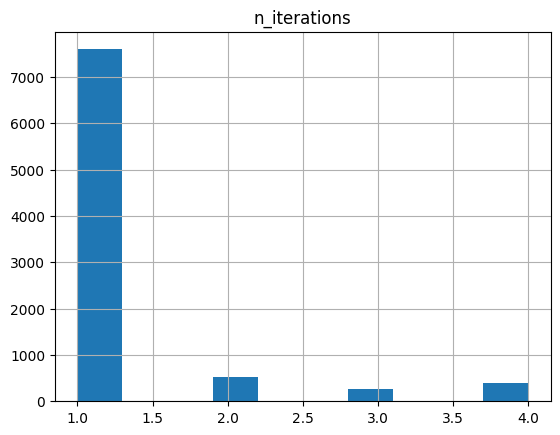

In [3]:
df = pro.simulation_dataframe()
no_converged = df[~df["converged"]]
df.hist("n_iterations")
#no_converged

In [4]:
T_wgo = pro.component("water_system").variable("T_WGO")
T_wgi = pro.component("water_system").variable("T_WGI")
T_wco = pro.component("water_system").variable("T_WCO")
T_wci= pro.component("water_system").variable("T_WCI")
f_load = pro.component("water_system").variable("generator_part_load")
Q_process = pro.component("water_system").variable("Q_process")
Q_loss = pro.component("water_system").variable("Q_loss")
Q_pump = pro.component("water_system").variable("Q_pump")
Q_gen = pro.component("water_system").variable("Q_gen")
delta_U = pro.component("water_system").variable("delta_U")


In [5]:
sim.plot(pro.dates(),[T_wgo,T_wgi])

In [7]:
sim.plot(pro.dates(),[Q_process])